In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [3]:
import kagglehub

path = kagglehub.dataset_download(
    "gokulrajkmv/unemployment-in-india"
)

print(path)

Using Colab cache for faster access to the 'unemployment-in-india' dataset.
/kaggle/input/unemployment-in-india


In [4]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/unemployment-in-india/Unemployment_Rate_upto_11_2020.csv
/kaggle/input/unemployment-in-india/Unemployment in India.csv
/kaggle/input/unemployment-in-india/.nfs000000009d25fcc100000016


In [5]:
df = pd.read_csv(path + "/Unemployment_Rate_upto_11_2020.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [6]:
print("Shape:", df.shape)

Shape: (267, 9)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [8]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


In [9]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Region.1,0
longitude,0
latitude,0


In [10]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')


In [11]:
df.rename(columns={
    'Region':'State',
    'Estimated Unemployment Rate (%)':'Unemployment_Rate',
    'Estimated Employed':'Employed',
    'Estimated Labour Participation Rate (%)':'Labour_Participation_Rate'
}, inplace=True)

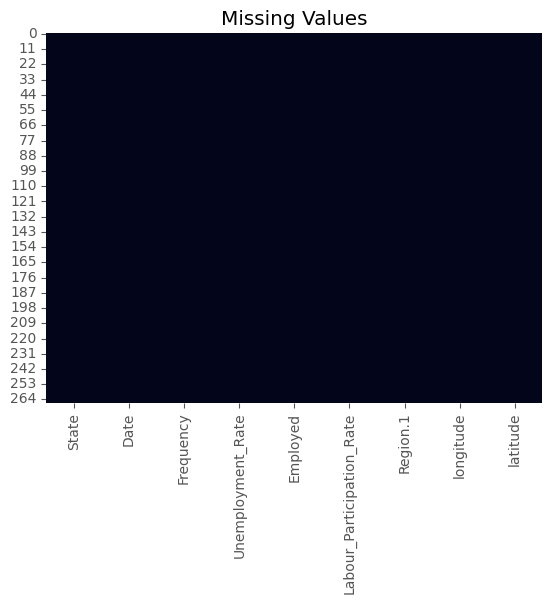

In [12]:
sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")
plt.show()

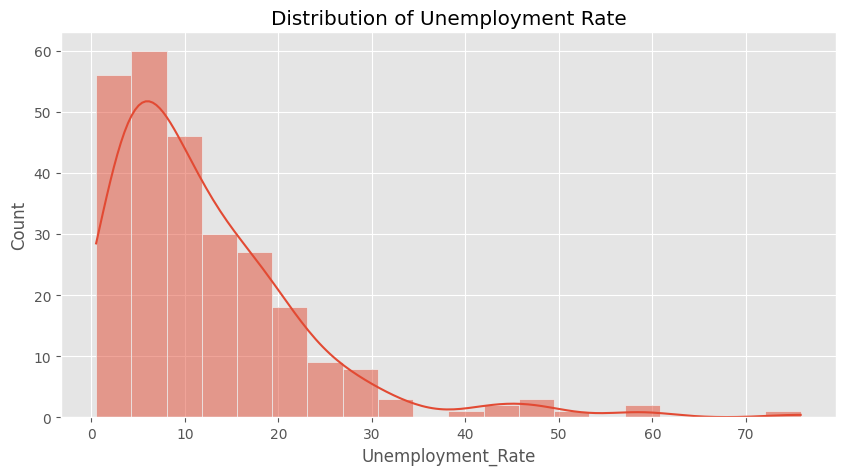

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Unemployment_Rate'],
    bins=20,
    kde=True
)

plt.title("Distribution of Unemployment Rate")
plt.show()

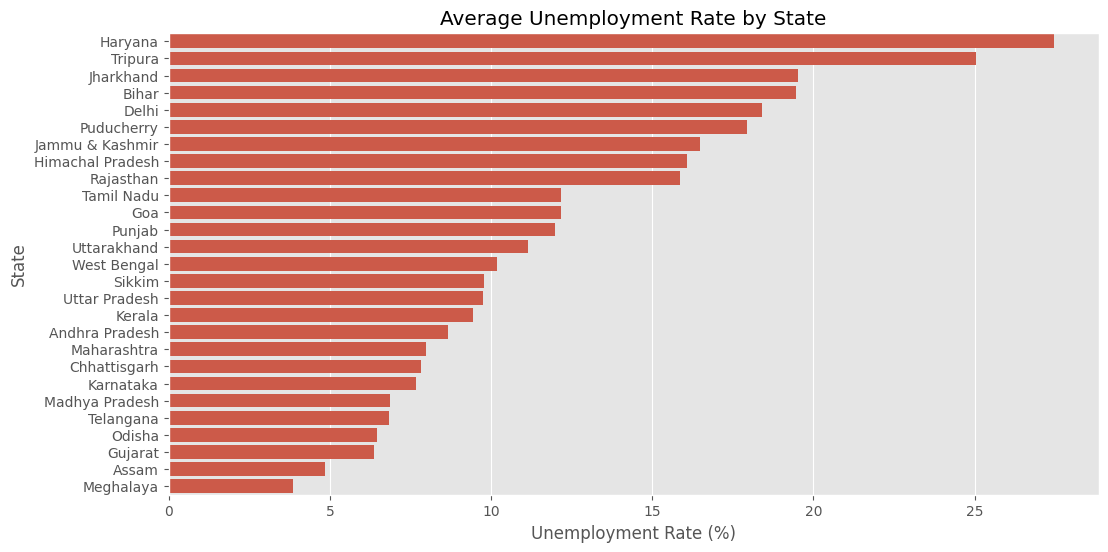

In [14]:
state_unemployment = df.groupby('State')[
    'Unemployment_Rate'
].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_unemployment.values,
    y=state_unemployment.index
)

plt.title("Average Unemployment Rate by State")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("State")

plt.show()

In [18]:
print(df.columns)

Index(['State', 'Date', 'Frequency', 'Unemployment_Rate', 'Employed',
       'Labour_Participation_Rate', 'Region.1', 'longitude', 'latitude'],
      dtype='object')


In [19]:
df.rename(columns={'Region.1':'Region'}, inplace=True)

print(df.columns)

Index(['State', 'Date', 'Frequency', 'Unemployment_Rate', 'Employed',
       'Labour_Participation_Rate', 'Region', 'longitude', 'latitude'],
      dtype='object')


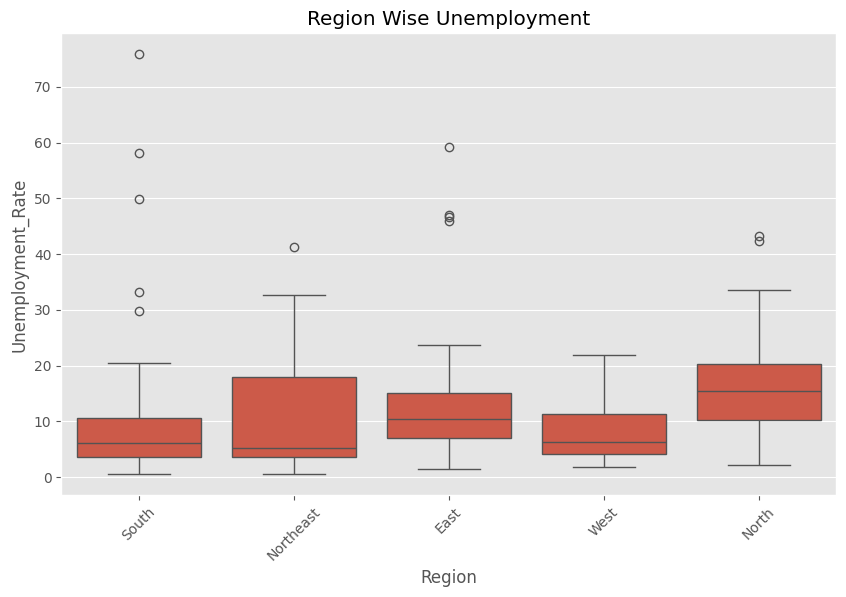

In [20]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Region',
    y='Unemployment_Rate',
    data=df
)

plt.xticks(rotation=45)

plt.title("Region Wise Unemployment")
plt.show()

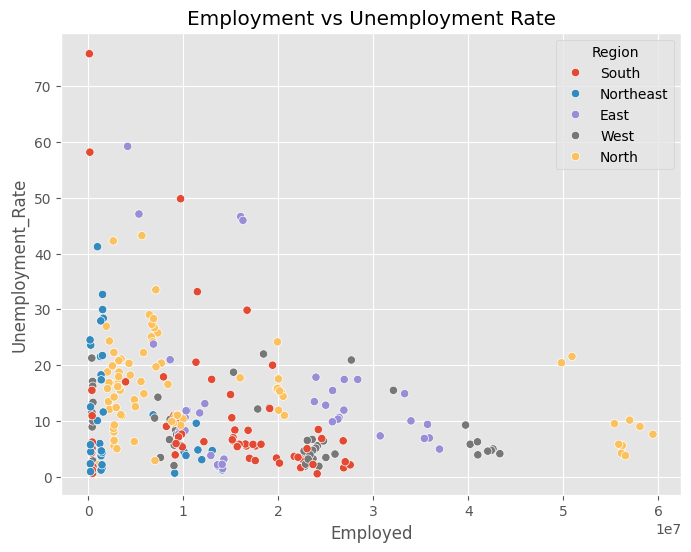

In [21]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Employed',
    y='Unemployment_Rate',
    hue='Region',
    data=df
)

plt.title("Employment vs Unemployment Rate")

plt.show()

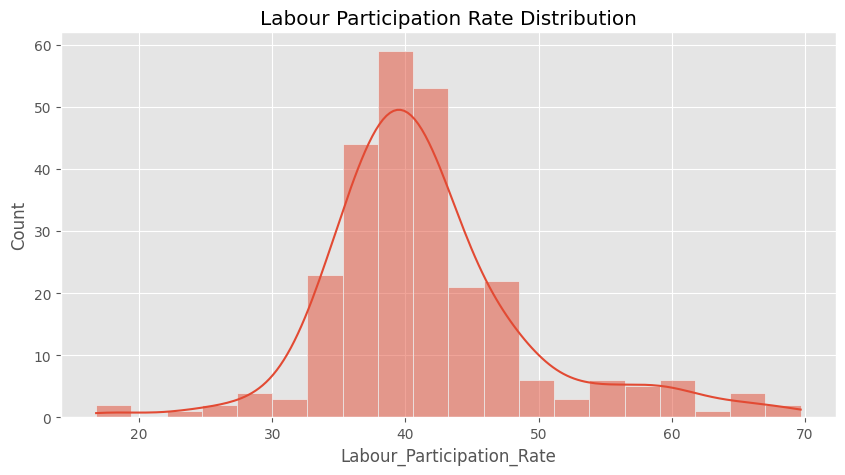

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Labour_Participation_Rate'],
    bins=20,
    kde=True
)

plt.title("Labour Participation Rate Distribution")

plt.show()

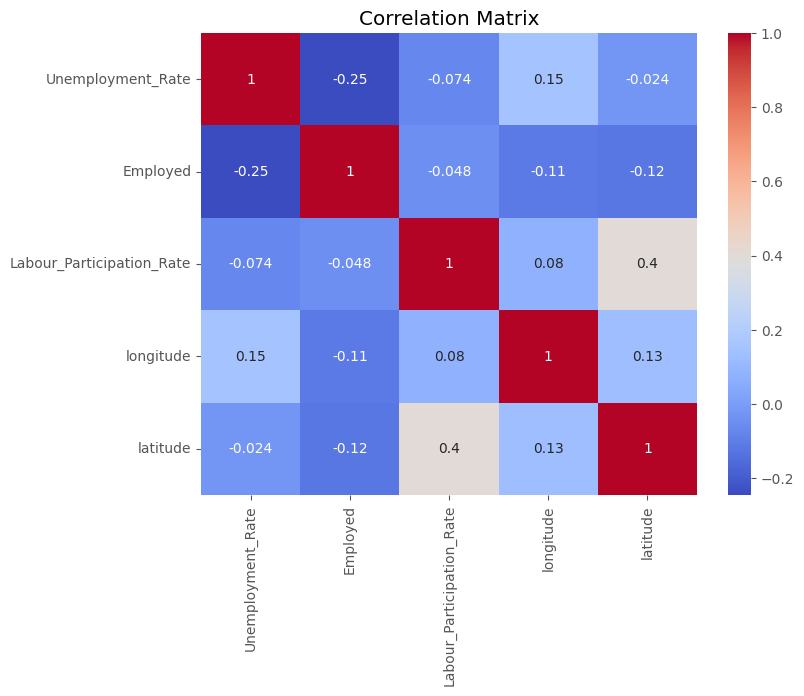

In [23]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

In [24]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month

/tmp/ipykernel_662/1590466412.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


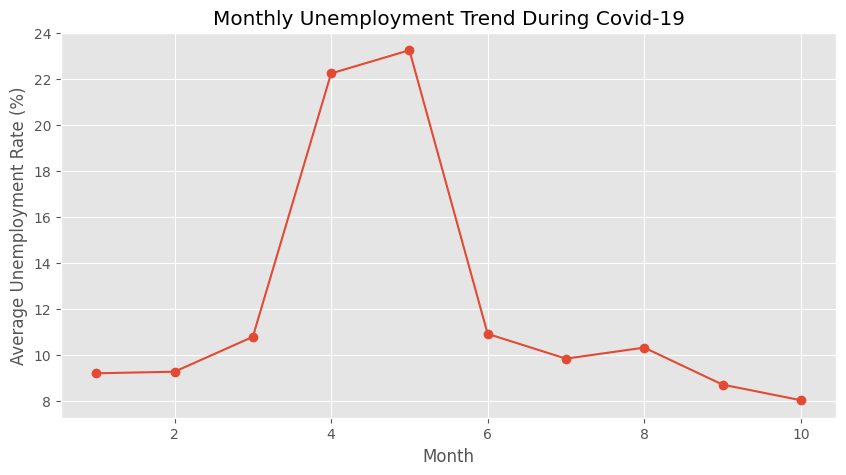

In [25]:
monthly = df.groupby('Month')[
    'Unemployment_Rate'
].mean()

plt.figure(figsize=(10,5))

monthly.plot(marker='o')

plt.title("Monthly Unemployment Trend During Covid-19")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.grid(True)

plt.show()

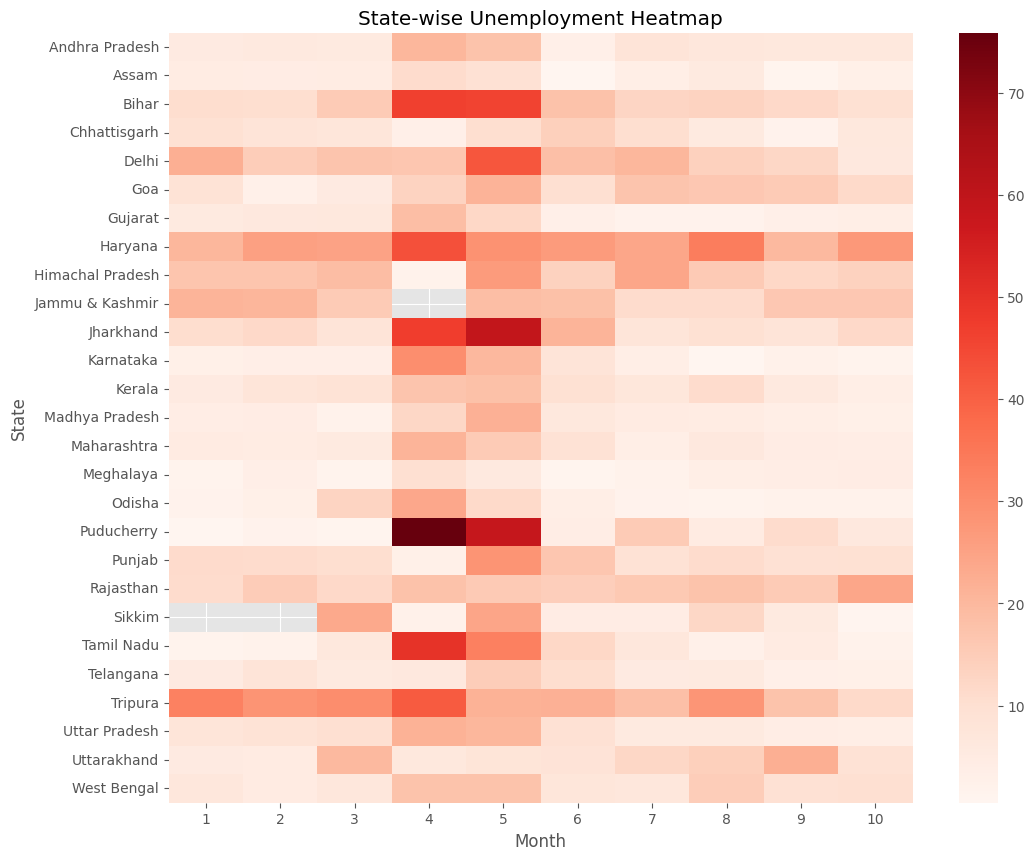

In [26]:
pivot = df.pivot_table(
    values='Unemployment_Rate',
    index='State',
    columns='Month'
)

plt.figure(figsize=(12,10))

sns.heatmap(
    pivot,
    cmap='Reds'
)

plt.title("State-wise Unemployment Heatmap")

plt.show()

# Conclusion :

Findings
Unemployment rate increased significantly during the Covid-19 period.
Some states experienced much higher unemployment than others.
Labour participation and employment levels varied considerably across regions.
Monthly analysis shows fluctuations corresponding to lockdown periods.
The dataset provides valuable insights into the economic impact of Covid-19 in India.
Tools Used
Python,
Pandas,
NumPy,
Matplotlib,
Seaborn,
Outcome.

Successfully analyzed unemployment trends in India and visualized the impact of Covid-19 on employment using Python.